# Part 2 - Q3: Pushover Check in ADRS Form

This notebook follows the method shown in the notes.

The key idea is:

1. take the **yield point** from the exported bilinear capacity curve,
2. compute the equivalent period `T*` from the **elastic branch**,
3. extend that elastic branch until it meets the EC8 demand spectrum,
4. read the elastic displacement `Sde`,
5. compute the target displacement `Sd`:

- if `T* > Tc`: `Sd = Sde`
- if `T* < Tc`: use the short-period formula

The notebook stays entirely in the exported `d*` coordinates. It does **not** convert to `u_top`.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.30
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo = Path.cwd()
images = repo / 'images'
images.mkdir(exist_ok=True)

## Input

In [14]:
# Student-ID digits used in the project files
A, B, C, D, E, F, G = 6, 6, 1, 1, 2, 5, 7

# EC8 spectrum parameters for Part 2, Q3
g = 9.81
gamma_I = 1.4
agR_g = 0.35 + 0.01 * C
ag_design_g = gamma_I * agR_g
ag_design = ag_design_g * g

S = 1.80
T_B = 0.10
T_C = 0.30
T_D = 1.20
xi = 5.0
eta = np.sqrt(10.0 / (5.0 + xi))
q = 1.0

capacity_csv = repo / 'push_over_capacity.csv'
bilinear_csv = repo / 'push_over_capacity_bilinear.csv'
save_figures = True

print(f'Student digits: A={A}, B={B}, C={C}, D={D}, E={E}, F={F}, G={G}')
print(f'agR = {agR_g:.3f} g = {agR_g * g:.3f} m/s²')
print(f'ag_design = {ag_design_g:.3f} g = {ag_design:.3f} m/s²')
print(f'S = {S}, TB = {T_B:.2f} s, TC = {T_C:.2f} s, TD = {T_D:.2f} s, eta = {eta:.3f}, q = {q:.1f}')

Student digits: A=6, B=6, C=1, D=1, E=2, F=5, G=7
agR = 0.360 g = 3.532 m/s²
ag_design = 0.504 g = 4.944 m/s²
S = 1.8, TB = 0.10 s, TC = 0.30 s, TD = 1.20 s, eta = 1.000, q = 1.0


## Load the RFEM Curves

In [4]:
capacity_df = pd.read_csv(capacity_csv, header=None, names=['d_star_mm', 'Sa_actual'])
capacity_df = capacity_df.groupby('d_star_mm', as_index=False)['Sa_actual'].mean().sort_values('d_star_mm').reset_index(drop=True)

bilinear_df = pd.read_csv(bilinear_csv, header=None, names=['d_star_mm', 'Sa_bilinear'])
bilinear_df = bilinear_df.groupby('d_star_mm', as_index=False)['Sa_bilinear'].mean().sort_values('d_star_mm').reset_index(drop=True)

disp_capacity_mm = capacity_df['d_star_mm'].to_numpy()
acc_capacity = capacity_df['Sa_actual'].to_numpy()

disp_bilinear_mm = bilinear_df['d_star_mm'].to_numpy()
acc_bilinear = bilinear_df['Sa_bilinear'].to_numpy()

disp_limit_mm = disp_capacity_mm[-1]

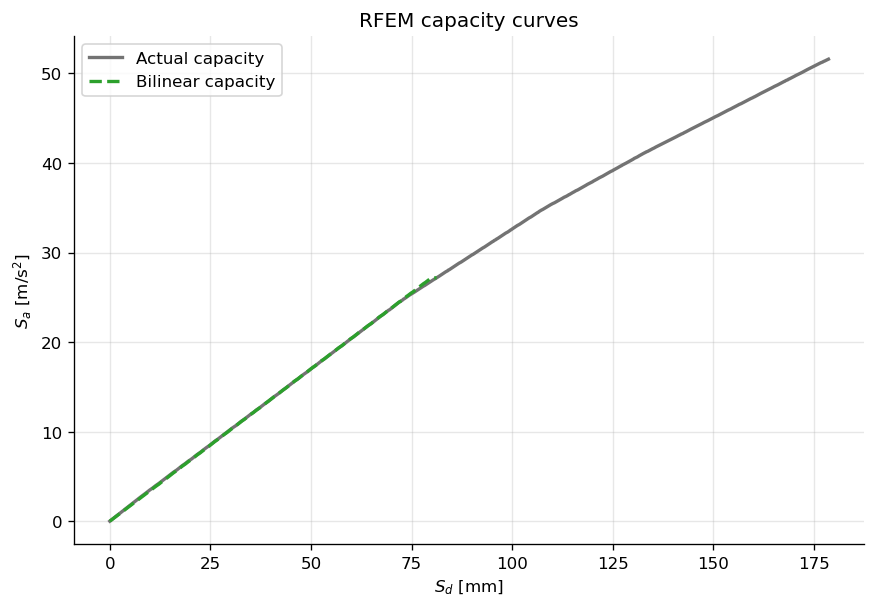

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(disp_capacity_mm, acc_capacity, color='0.45', linewidth=2.0, label='Actual capacity')
ax.plot(disp_bilinear_mm, acc_bilinear, color='tab:green', linestyle='--', linewidth=2.0, label='Bilinear capacity')
ax.set_xlabel(r'$S_d$ [mm]')
ax.set_ylabel(r'$S_a$ [m/s$^2$]')
ax.set_title('RFEM capacity curves')
ax.legend(loc='best')
plt.show()

if save_figures:
    fig.savefig(images / 'part2_q3_capacity_curves.png', bbox_inches='tight')

## Yield Point of the Bilinear Capacity

The yield point is taken as the **first point of the plateau** in the bilinear export.
That defines the elastic branch used for the ADRS check.

In [6]:
yield_acc = acc_bilinear.max()
yield_index = np.where(np.isclose(acc_bilinear, yield_acc))[0][0]
yield_disp_mm = disp_bilinear_mm[yield_index]

yield_slope = yield_acc / yield_disp_mm
T_star = 2.0 * np.pi * np.sqrt((yield_disp_mm / 1000.0) / yield_acc)

print(f'Yield displacement Sdy = {yield_disp_mm:.2f} mm')
print(f'Yield acceleration Say = {yield_acc:.2f} m/s^2')
print(f'Elastic-branch slope = {yield_slope:.4f} (m/s^2)/mm')
print(f'Equivalent period T* = {T_star:.4f} s')

Yield displacement Sdy = 79.90 mm
Yield acceleration Say = 27.17 m/s^2
Elastic-branch slope = 0.3401 (m/s^2)/mm
Equivalent period T* = 0.3407 s


## EC8 Elastic Spectrum

In [7]:
def ec8_sa(period_s, scale=1.0):
    period_s = np.asarray(period_s, dtype=float)
    sa = np.zeros_like(period_s)

    part_1 = period_s <= T_B
    part_2 = (period_s > T_B) & (period_s <= T_C)
    part_3 = (period_s > T_C) & (period_s <= T_D)
    part_4 = period_s > T_D

    sa[part_1] = scale * ag_design * S * (1.0 + (period_s[part_1] / T_B) * (2.5 * eta - 1.0))
    sa[part_2] = scale * ag_design * S * 2.5 * eta
    sa[part_3] = scale * ag_design * S * 2.5 * eta * (T_C / period_s[part_3])
    sa[part_4] = scale * ag_design * S * 2.5 * eta * (T_C * T_D / period_s[part_4] ** 2)

    return sa

## Design Target Displacement

The design displacement is obtained from the elastic-branch line, not from the horizontal part of the bilinear curve.

In [8]:
Sae_design = ec8_sa(np.array([T_star]), scale=1.0)[0]
Sde_design_mm = Sae_design * T_star**2 / (4.0 * np.pi**2) * 1000.0
Rmu_design = Sae_design / yield_acc

if T_star > T_C:
    design_case = 'long-period'
    Sd_design_mm = Sde_design_mm
else:
    design_case = 'short-period'
    Sd_design_mm = (Sde_design_mm / Rmu_design) * (((Rmu_design - 1.0) * T_C / T_star) + 1.0)

design_table = pd.DataFrame([
    ['Case', design_case],
    ['Equivalent period T* [s]', T_star],
    ['Corner period Tc [s]', T_C],
    ['Yield displacement Sdy [mm]', yield_disp_mm],
    ['Yield acceleration Say [m/s^2]', yield_acc],
    ['Elastic displacement Sde [mm]', Sde_design_mm],
    ['Elastic acceleration Sae [m/s^2]', Sae_design],
    ['Ductility factor Rmu [-]', Rmu_design],
    ['Target displacement Sd [mm]', Sd_design_mm],
    ['Actual displacement capacity du* [mm]', disp_limit_mm],
], columns=['Quantity', 'Value'])

design_table

,Quantity,Value
0,Case,long-period
1,Equivalent period T* [s],0.340728
2,Corner period Tc [s],0.3
3,Yield displacement Sdy [mm],79.9
4,Yield acceleration Say [m/s^2],27.17
5,Elastic displacement Sde [mm],57.607896
6,Elastic acceleration Sae [m/s^2],19.589569
7,Ductility factor Rmu [-],0.721
8,Target displacement Sd [mm],57.607896
9,Actual displacement capacity du* [mm],178.6


In [9]:
if Sd_design_mm < disp_limit_mm:
    print('SAFE: target displacement Sd is smaller than the available displacement capacity du*.')
else:
    print('NOT SAFE: target displacement Sd reaches or exceeds du*.')

SAFE: target displacement Sd is smaller than the available displacement capacity du*.


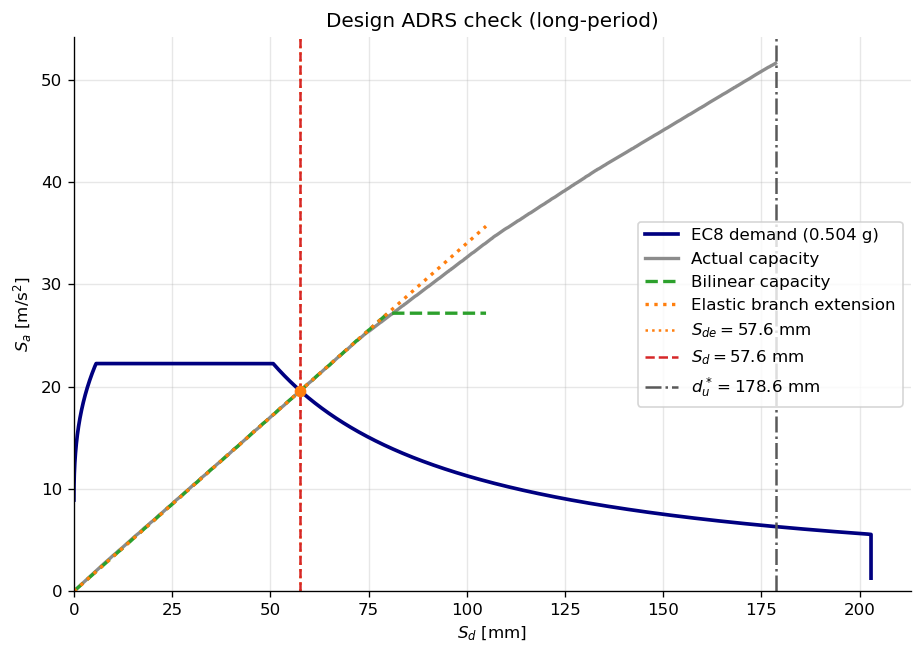

In [10]:
period_plot = np.linspace(1e-4, 2.5, 40000)
sa_design_curve = ec8_sa(period_plot, scale=1.0)
sd_design_curve_mm = sa_design_curve * period_plot**2 / (4.0 * np.pi**2) * 1000.0

plateau_display_end_mm = max(yield_disp_mm + 25.0, 1.2 * yield_disp_mm)
disp_bilinear_plot_mm = np.append(disp_bilinear_mm, plateau_display_end_mm)
acc_bilinear_plot = np.append(acc_bilinear, yield_acc)

sd_line_mm = np.linspace(0.0, max(1.15 * Sde_design_mm, plateau_display_end_mm), 300)
sa_line = yield_slope * sd_line_mm

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sd_design_curve_mm, sa_design_curve, color='navy', linewidth=2.2, label=fr'EC8 demand ({ag_design_g:.3f} g)')
ax.plot(disp_capacity_mm, acc_capacity, color='0.55', linewidth=2.0, label='Actual capacity')
ax.plot(disp_bilinear_plot_mm, acc_bilinear_plot, color='tab:green', linestyle='--', linewidth=2.0, label='Bilinear capacity')
ax.plot(sd_line_mm, sa_line, color='tab:orange', linestyle=':', linewidth=2.0, label='Elastic branch extension')
ax.scatter(Sde_design_mm, Sae_design, color='tab:orange', zorder=4)
ax.axvline(Sde_design_mm, color='tab:orange', linestyle=':', linewidth=1.5, label=fr'$S_{{de}}={Sde_design_mm:.1f}$ mm')
ax.axvline(Sd_design_mm, color='tab:red', linestyle='--', linewidth=1.5, label=fr'$S_d={Sd_design_mm:.1f}$ mm')
ax.axvline(disp_limit_mm, color='0.35', linestyle='-.', linewidth=1.5, label=fr'$d_u^*={disp_limit_mm:.1f}$ mm')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$S_d$ [mm]')
ax.set_ylabel(r'$S_a$ [m/s$^2$]')
ax.set_title(f'Design ADRS check ({design_case})')
ax.legend(loc='best')
plt.show()

if save_figures:
    fig.savefig(images / 'part2_q3_design_adrs.png', bbox_inches='tight')

## Failure `a_g` by Iteration

The demand spectrum is scaled until the target displacement reaches the actual displacement capacity.

In [11]:
step = 0.05
scale = 1.0
last_safe_scale = 1.0
last_safe_Sde = Sde_design_mm
last_safe_Sd = Sd_design_mm
last_safe_Sae = Sae_design
last_safe_Rmu = Rmu_design
last_safe_case = design_case

first_fail_scale = None

while scale <= 6.0:
    Sae = ec8_sa(np.array([T_star]), scale=scale)[0]
    Sde_mm = Sae * T_star**2 / (4.0 * np.pi**2) * 1000.0
    Rmu = Sae / yield_acc

    if T_star > T_C:
        Sd_mm = Sde_mm
        case_name = 'long-period'
    else:
        Sd_mm = (Sde_mm / Rmu) * (((Rmu - 1.0) * T_C / T_star) + 1.0)
        case_name = 'short-period'

    if Sd_mm >= disp_limit_mm:
        first_fail_scale = scale
        break

    last_safe_scale = scale
    last_safe_Sde = Sde_mm
    last_safe_Sd = Sd_mm
    last_safe_Sae = Sae
    last_safe_Rmu = Rmu
    last_safe_case = case_name
    scale += step

low_scale = first_fail_scale - step
high_scale = first_fail_scale

for _ in range(50):
    mid_scale = 0.5 * (low_scale + high_scale)
    Sae = ec8_sa(np.array([T_star]), scale=mid_scale)[0]
    Sde_mm = Sae * T_star**2 / (4.0 * np.pi**2) * 1000.0
    Rmu = Sae / yield_acc

    if T_star > T_C:
        Sd_mm = Sde_mm
    else:
        Sd_mm = (Sde_mm / Rmu) * (((Rmu - 1.0) * T_C / T_star) + 1.0)

    if Sd_mm >= disp_limit_mm:
        high_scale = mid_scale
    else:
        low_scale = mid_scale
        last_safe_scale = mid_scale
        last_safe_Sde = Sde_mm
        last_safe_Sd = Sd_mm
        last_safe_Sae = Sae
        last_safe_Rmu = Rmu

failure_scale = high_scale
failure_ag_g = failure_scale * ag_design_g

failure_table = pd.DataFrame([
    ['Last safe scale [-]', last_safe_scale],
    ['Failure scale [-]', failure_scale],
    ['Failure acceleration ag_fail [g]', failure_ag_g],
    ['Last safe case', last_safe_case],
    ['Last safe elastic displacement Sde [mm]', last_safe_Sde],
    ['Last safe target displacement Sd [mm]', last_safe_Sd],
    ['Last safe elastic acceleration Sae [m/s^2]', last_safe_Sae],
    ['Last safe ductility factor Rmu [-]', last_safe_Rmu],
], columns=['Quantity', 'Value'])

failure_table

,Quantity,Value
0,Last safe scale [-],3.100269
1,Failure scale [-],3.100269
2,Failure acceleration ag_fail [g],1.562536
3,Last safe case,long-period
4,Last safe elastic displacement Sde [mm],178.6
5,Last safe target displacement Sd [mm],178.6
6,Last safe elastic acceleration Sae [m/s^2],60.732941
7,Last safe ductility factor Rmu [-],2.235294


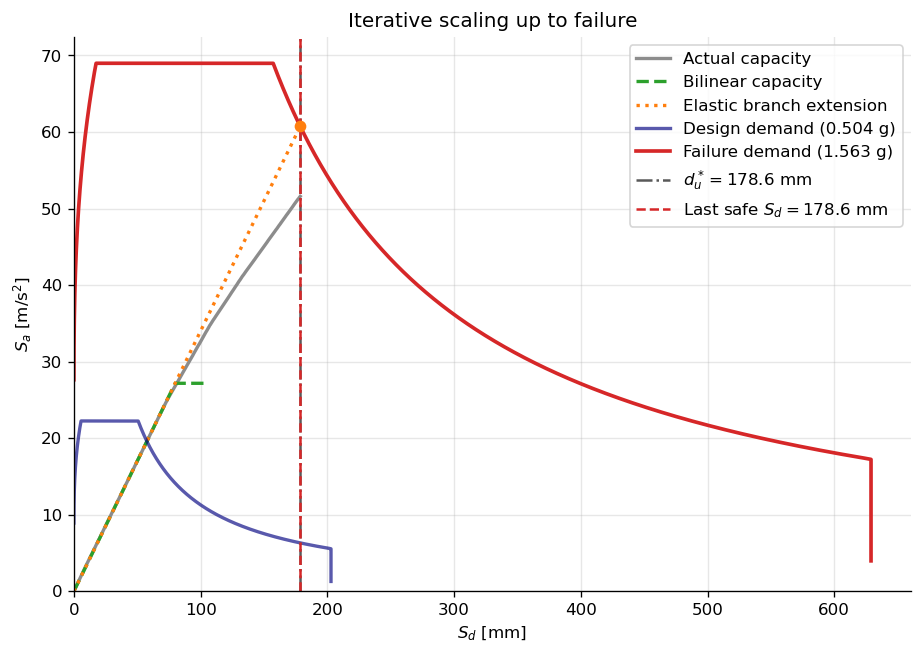

In [12]:
period_fail = np.linspace(1e-4, 2.5, 40000)
sa_fail_curve = ec8_sa(period_fail, scale=failure_scale)
sd_fail_curve_mm = sa_fail_curve * period_fail**2 / (4.0 * np.pi**2) * 1000.0

sd_line_fail_mm = np.linspace(0.0, last_safe_Sd, 500)
sa_line_fail = yield_slope * sd_line_fail_mm

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(disp_capacity_mm, acc_capacity, color='0.55', linewidth=2.0, label='Actual capacity')
ax.plot(disp_bilinear_plot_mm, acc_bilinear_plot, color='tab:green', linestyle='--', linewidth=2.0, label='Bilinear capacity')
ax.plot(sd_line_fail_mm, sa_line_fail, color='tab:orange', linestyle=':', linewidth=2.0, label='Elastic branch extension')
ax.plot(sd_design_curve_mm, sa_design_curve, color='navy', linewidth=2.0, alpha=0.65, label=fr'Design demand ({ag_design_g:.3f} g)')
ax.plot(sd_fail_curve_mm, sa_fail_curve, color='tab:red', linewidth=2.2, label=fr'Failure demand ({failure_ag_g:.3f} g)')
ax.scatter(last_safe_Sd, last_safe_Sae, color='tab:orange', zorder=4)
ax.axvline(disp_limit_mm, color='0.35', linestyle='-.', linewidth=1.5, label=fr'$d_u^*={disp_limit_mm:.1f}$ mm')
ax.axvline(last_safe_Sd, color='tab:red', linestyle='--', linewidth=1.5, label=fr'Last safe $S_d={last_safe_Sd:.1f}$ mm')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$S_d$ [mm]')
ax.set_ylabel(r'$S_a$ [m/s$^2$]')
ax.set_title('Iterative scaling up to failure')
ax.legend(loc='best')
plt.show()

if save_figures:
    fig.savefig(images / 'part2_q3_failure_scaling.png', bbox_inches='tight')

## Final Remarks

- `Sde` is obtained from the **extension of the elastic branch** of the bilinear curve.
- For this structure, `T*` is compared with `Tc` to decide whether case (a) or case (b) applies.
- The actual RFEM curve is used only for the displacement capacity check.
- The failure acceleration is found by scaling the demand until the target displacement reaches that capacity.